In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [45]:
df = pd.read_csv('Reservas auditado.csv', sep=';')
df

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão De Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,Pix
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão De Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,Cancelada,Pix
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,Confirmada,Cartão De Débito
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,Confirmada,Pix
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,Confirmada,Transferência
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,Concluída,Cartão De Débito


In [46]:
#Quantidade de diarias por trimestre em linha (sem Canceladas)

#mudar o tipo da coluna data_checkin para datetime
df['data_checkin'] = pd.to_datetime(df['data_checkin'])

#filtrar as reservas que não estão canceladas
df_sem_canceladas = df[df['status_reserva'] != 'Cancelada']

#agrupar por trimestre e contar a quantidade de diarias
qtd_diarias_por_trimestre = (
    df_sem_canceladas
    .groupby(df_sem_canceladas['data_checkin'].dt.to_period('Q').astype(str))['qtd_diarias']
    .sum()
    .reset_index()
)

print(qtd_diarias_por_trimestre)

  data_checkin  qtd_diarias
0       2023Q1          835
1       2023Q2          861
2       2023Q3         1051
3       2023Q4          934
4       2024Q1         1016
5       2024Q2          983
6       2024Q3          876
7       2024Q4          873


In [47]:
#Formas de pagamento por canal (cruzamento de colunas)

pagamento_canal = pd.crosstab(
    df['id_canal'],
    df['forma_pagamento']
)

pagamento_canal['Total'] = pagamento_canal.sum(axis=1)

pagamento_canal

forma_pagamento,Cartão De Crédito,Cartão De Débito,Dinheiro,Pix,Transferência,Total
id_canal,,,,,,
1.0,146,152,149,152,165,764
2.0,148,156,163,151,154,772
3.0,75,82,80,73,57,367
4.0,81,90,97,98,76,442


C:\Users\lucas.avelar\AppData\Local\Temp\ipykernel_31232\1777077200.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


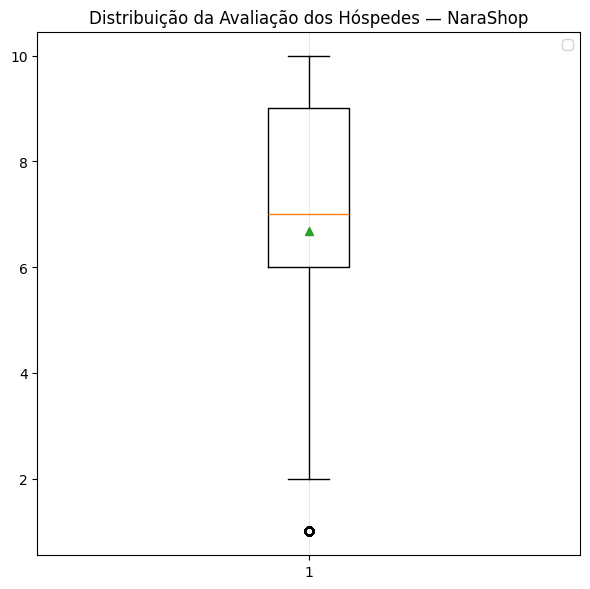

In [48]:
#Boxplot da avaliação dos clientes

array_aval = np.array(df['avaliacao_hospede'])
array_aval = df['avaliacao_hospede'].dropna()

minimo = array_aval.min()
maximo = array_aval.max()
amplitude = maximo - minimo

mediana = np.median(array_aval)

q1 = np.percentile(array_aval, 25)
q3 = np.percentile(array_aval, 75)

plt.figure(figsize=(6, 6))

plt.boxplot(array_aval, vert=True, showmeans=True)
plt.title('Distribuição da Avaliação dos Hóspedes — NaraShop')
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
#Estatísticas descritivas do valor unitário (desconsiderando os nulos)

aval = df['avaliacao_hospede'].dropna()

media   = aval.mean()
mediana = aval.median()
desvio  = aval.std()
q1      = np.percentile(aval, 25)
q3      = np.percentile(aval, 75)
minimo  = aval.min()
maximo  = aval.max()
iqr = q3 - q1
out_inf = q1 - 1.5 * iqr
out_sup = q3 + 1.5 * iqr

print(f'Média:          {media:.2f}')
print(f'Mediana:        {mediana:.2f}')
print(f'Desvio Padrão:  {desvio:.2f}')
print(f'Q1:             {q1:.2f}')
print(f'Q3:             {q3:.2f}')
print(f'Mínimo:         {minimo:.2f}')
print(f'Máximo:         {maximo:.2f}')
print(f'IQR:            {iqr:.2f}')
print(f'Outliers Inferiores: {out_inf:.2f}')
print(f'Outliers Superiores: {out_sup:.2f}')

df['avaliacao_hospede'].max()

Média:          6.68
Mediana:        7.00
Desvio Padrão:  2.76
Q1:             6.00
Q3:             9.00
Mínimo:         1.00
Máximo:         10.00
IQR:            3.00
Outliers Inferiores: 1.50
Outliers Superiores: 13.50


np.float64(10.0)

In [50]:
# 1. Carregando e tratando os dados de acordo com os passos anteriores do notebook
df = pd.read_csv('reservas auditado.csv', sep=';')
df['data_checkin'] = pd.to_datetime(df['data_checkin'])

# Preparação dos dados para o Gráfico de Linha (Filtrando canceladas)
df_sem_canceladas = df[df['status_reserva'] != 'Cancelada']
qtd_diarias_por_trimestre = df_sem_canceladas.groupby(df_sem_canceladas['data_checkin'].dt.to_period('Q'))['qtd_diarias'].sum()

# Convertendo o índice de períodos para string para plotar corretamente no eixo X
x_linha = qtd_diarias_por_trimestre.index.astype(str)
y_linha = qtd_diarias_por_trimestre.values

# Preparação dos dados para o Gráfico de Barras (Cruzamento existente)
pagamento_canal = pd.crosstab(df['id_canal'], df['forma_pagamento'])
pagamento_canal['Total'] = pagamento_canal.sum(axis=1)

# Preparação dos dados para o Boxplot e Texto (Removendo nulos da avaliação)
aval = df['avaliacao_hospede'].dropna()
media = aval.mean()
mediana = aval.median()
desvio = aval.std()
q1 = np.percentile(aval, 25)
q3 = np.percentile(aval, 75)

C:\Users\lucas.avelar\AppData\Local\Temp\ipykernel_31232\1767267329.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\lucas.avelar\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


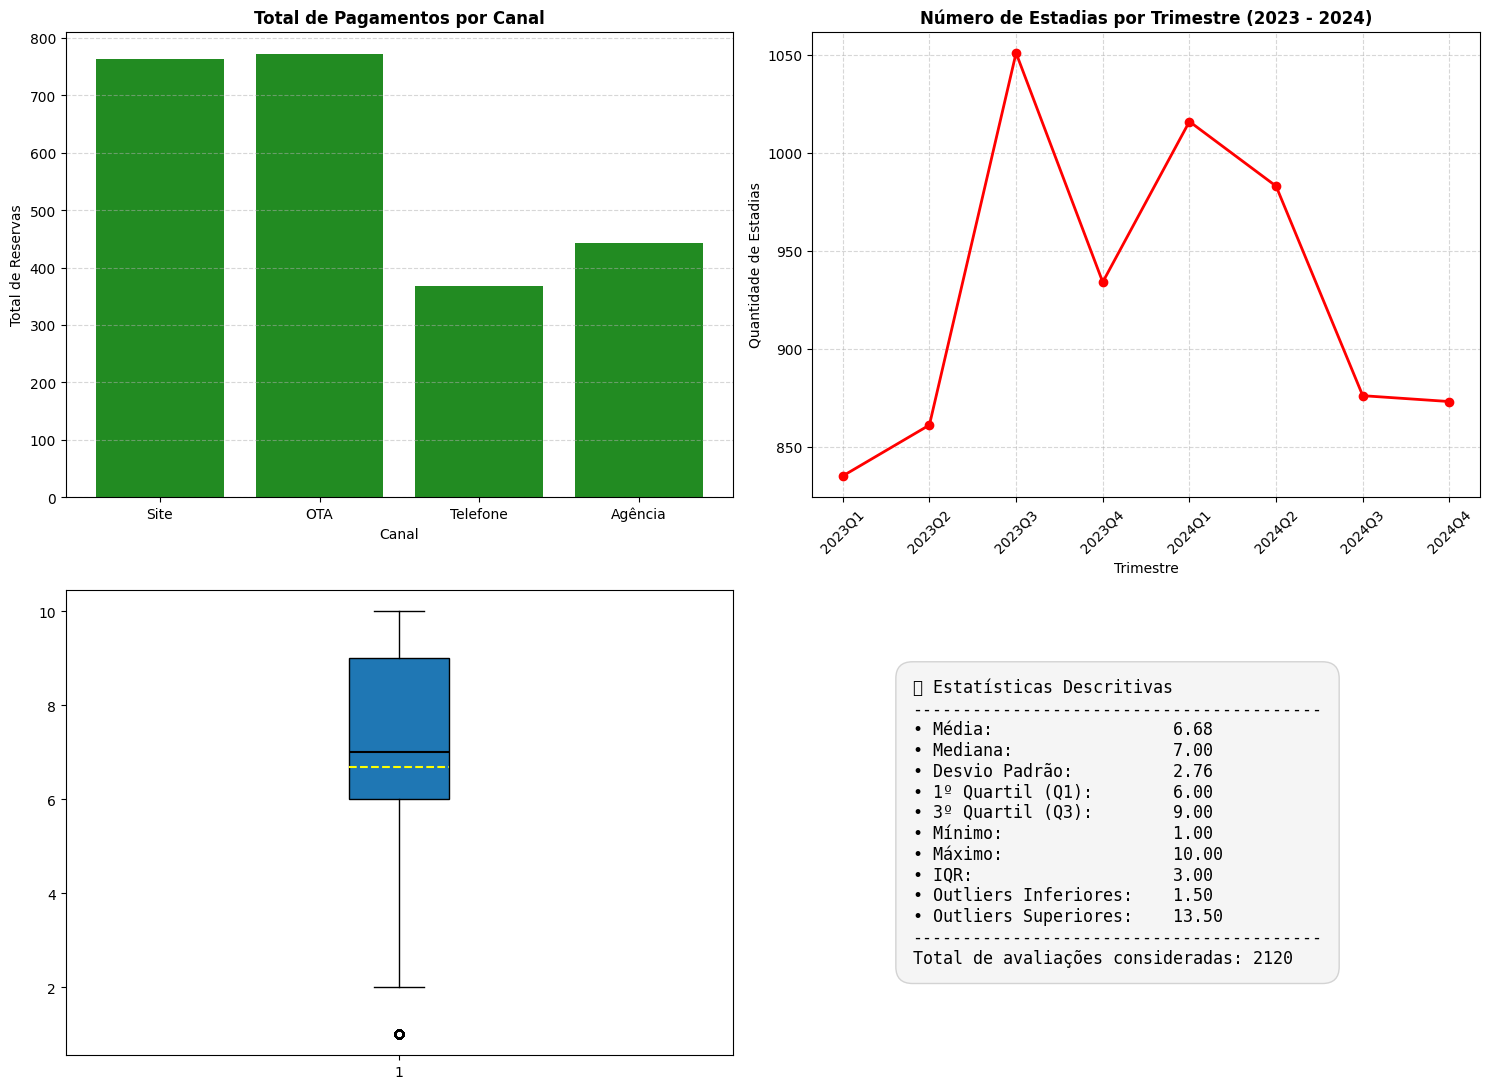

In [51]:
# ------------------ CONSTRUÇÃO DO PAINEL 2X2 ------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 11))

# --- axes[0][0]: Gráfico de Barras  ---
mapa_canais = {1: 'Site', 2: 'OTA', 3: 'Telefone', 4: 'Agência'}
axes[0][0].bar(
    pagamento_canal.index.map(mapa_canais),
    pagamento_canal['Total'],
    color='#228B22'
)
axes[0][0].set_title('Total de Pagamentos por Canal', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('Canal')
axes[0][0].set_ylabel('Total de Reservas')
axes[0][0].grid(axis='y', linestyle='--', alpha=0.5)


# --- axes[0][1]: Gráfico de Linha (Estadias por Trimestre) ---
axes[0][1].plot(x_linha, y_linha, marker='o', color='#FF0000', linewidth=2, label='Estadias')
axes[0][1].set_title('Número de Estadias por Trimestre (2023 - 2024)', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Trimestre')
axes[0][1].set_ylabel('Quantidade de Estadias')
axes[0][1].grid(True, linestyle='--', alpha=0.5)
# Rotacionando os rótulos do eixo X para melhor leitura
axes[0][1].tick_params(axis='x', rotation=45) 


# --- axes[1][0]: Boxplot (Avaliação de Clientes) ---
box = axes[1][0].boxplot(aval, vert=True, showmeans=True, meanline=True, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 1.5},
                         meanprops={'linestyle': '--', 'color': 'yellow', 'linewidth': 1.5})


# --- axes[1][1]: Quadro de Texto (Estatísticas Descritivas) ---
axes[1][1].axis('off') # Remove as bordas dos eixos tradicionais

# Criação de colunas com espaçamento idêntico usando f-strings
# O ':25' garante que a primeira coluna tenha sempre exatamente 25 caracteres de largura
texto_estatisticas = (
    f"📊 Estatísticas Descritivas\n"
    f"-----------------------------------------\n"
    f"{'• Média:':25} {media:.2f}\n"
    f"{'• Mediana:':25} {mediana:.2f}\n"
    f"{'• Desvio Padrão:':25} {desvio:.2f}\n"
    f"{'• 1º Quartil (Q1):':25} {q1:.2f}\n"
    f"{'• 3º Quartil (Q3):':25} {q3:.2f}\n"
    f"{'• Mínimo:':25} {minimo:.2f}\n"
    f"{'• Máximo:':25} {maximo:.2f}\n"
    f"{'• IQR:':25} {iqr:.2f}\n"
    f"{'• Outliers Inferiores:':25} {out_inf:.2f}\n"
    f"{'• Outliers Superiores:':25} {out_sup:.2f}\n"
    f"-----------------------------------------\n"
    f"Total de avaliações consideradas: {len(aval)}"
)

# Adicionando o texto centralizado no quadrante correspondente
axes[1][1].text(
    0.15, 0.5, 
    texto_estatisticas, 
    fontsize=12, 
    fontfamily='monospace', # OBRIGATÓRIO: garante que cada caractere/espaço tenha a mesma largura
    verticalalignment='center',
    bbox=dict(boxstyle='round,pad=1', facecolor='#F5F5F5', edgecolor='#D3D3D3')
)


# Ajuste fino de layout para evitar sobreposições de textos dos eixos
plt.tight_layout()
plt.show()